<a href="https://colab.research.google.com/github/Keen2640/Low-Power-Edge-AI-Acoustic-Classifier/blob/main/tinyml_sound_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa tensorflow


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [3]:
# Download mini Speech Commands dataset from Google storage
!wget http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip
# Unzip it silently
!unzip -q mini_speech_commands.zip
print("Google Speech Dataset downloaded and extracted successfully!")

--2026-05-29 00:34:53--  http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.121.207, 192.178.142.207, 142.251.108.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.121.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182082353 (174M) [application/zip]
Saving to: ‘mini_speech_commands.zip’

mini_speech_command 100%[===================>] 173.65M   232MB/s    in 0.7s    

2026-05-29 00:34:54 (232 MB/s) - ‘mini_speech_commands.zip’ saved [182082353/182082353]

Google Speech Dataset downloaded and extracted successfully!


In [5]:
IMG_SIZE = 64

def create_spectrogram(file_path):
    # Load audio at a fixed sample rate of 16kHz
    audio, sample_rate = librosa.load(file_path, sr=16000, duration=1.0)

    # Pad short audio clips to ensure they are exactly 1 second
    if len(audio) < 16000:
        audio = np.pad(audio, (0, 16000 - len(audio)), 'constant')

    # Compute the mathematical Mel Spectrogram
    spectrogram = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate,
        n_mels=64
    )

    # Convert to decibel units
    spectrogram_db = librosa.power_to_db(spectrogram)

    return spectrogram_db

Testing with file: mini_speech_commands/yes/4845bb10_nohash_1.wav


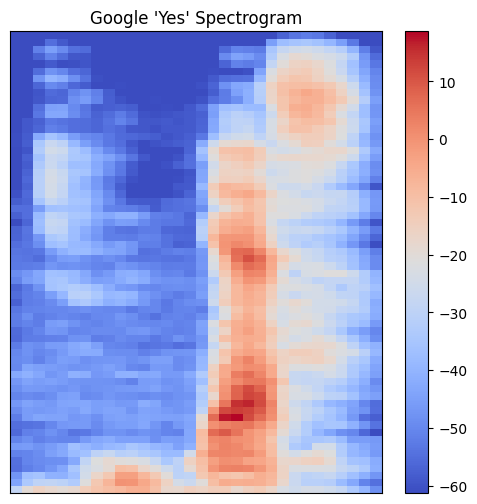

In [7]:
# Automatically find the very first .wav file inside the 'yes' folder
yes_folder = "mini_speech_commands/yes"
all_files = [f for f in os.listdir(yes_folder) if f.endswith('.wav')]
first_file_path = os.path.join(yes_folder, all_files[0])

print(f"Testing with file: {first_file_path}")

# Generate the spectrogram for that file
spec = create_spectrogram(first_file_path)

# Draw the image map
plt.figure(figsize=(6,6))
librosa.display.specshow(spec)
plt.colorbar()
plt.title(f"Google 'Yes' Spectrogram")
plt.show()

In [10]:
X = []
y = []

# Let's see what folders actually exist inside your dataset
available_folders = os.listdir("mini_speech_commands")
print("Folders found in dataset:", available_folders)

# Build our target 3 classes based on what's actually there
classes = ["yes", "no"]

# Look for ANY folder that sounds like background noise
noise_folder = None
for folder in available_folders:
    if "noise" in folder.lower():
        noise_folder = folder
        break

if noise_folder:
    classes.append(noise_folder)
else:
    # If no noise folder exists, grab another word (like 'up') to use as our 3rd class!
    fallback = [f for f in available_folders if f not in ["yes", "no", ".DS_Store"]][0]
    classes.append(fallback)

print(f"Training the AI to distinguish between these 3 classes: {classes}\n")

for label, class_name in enumerate(classes):
    folder = f"mini_speech_commands/{class_name}"

    # Grab up to 100 .wav files from the folder
    files = [f for f in os.listdir(folder) if f.endswith('.wav')][:100]

    print(f"Processing {len(files)} files from folder: {class_name}...")

    for file in files:
        path = os.path.join(folder, file)
        try:
            spec = create_spectrogram(path)
            # Resize image to a strict 64x64 grid with 1 color channel (grayscale)
            spec = tf.image.resize(spec[..., np.newaxis], [64, 64]).numpy()
            X.append(spec)
            y.append(label)
        except Exception as e:
            pass # Skips any individual corrupted files seamlessly

X = np.array(X)
y = np.array(y)

print("\n--- Data Loading Complete ---")
print("Data Matrix Shape (Images):", X.shape)
print("Labels Array Shape:", y.shape)

Folders found in dataset: ['down', 'yes', 'right', 'no', 'README.md', 'up', 'stop', 'left', 'go']
Training the AI to distinguish between these 3 classes: ['yes', 'no', 'down']

Processing 100 files from folder: yes...
Processing 100 files from folder: no...
Processing 100 files from folder: down...

--- Data Loading Complete ---
Data Matrix Shape (Images): (300, 64, 64, 1)
Labels Array Shape: (300,)


In [11]:
# Convert numerical labels (0, 1, 2) to one-hot encoded binary arrays
y_encoded = to_categorical(y)

# Split data: 80% for training the AI, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training dataset (spectrogram images):", X_train.shape)
print("Testing dataset (spectrogram images):", X_test.shape)

Training dataset (spectrogram images): (240, 64, 64, 1)
Testing dataset (spectrogram images): (60, 64, 64, 1)


In [12]:
model = Sequential()

# Layer 1: Scan the 64x64 grayscale spectrogram image using 8 moving filters
model.add(Conv2D(8, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D((2,2)))

# Layer 2: Extract deeper, more complex frequency patterns using 16 filters
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten the 2D image matrices into a single line of data clues
model.add(Flatten())

# Classification layers to calculate probabilities for your 3 sound classes
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile the neural network configurations
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,731 (397.39 KB)

 Trainable params: 101,731 (397.39 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Start the training process
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.3542 - loss: 4.0211 - val_accuracy: 0.3500 - val_loss: 1.6982
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.3833 - loss: 1.3448 - val_accuracy: 0.5667 - val_loss: 0.8942
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5958 - loss: 0.8933 - val_accuracy: 0.6667 - val_loss: 0.8562
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6708 - loss: 0.7441 - val_accuracy: 0.6667 - val_loss: 0.7265
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7292 - loss: 0.6177 - val_accuracy: 0.7333 - val_loss: 0.6960
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8042 - loss: 0.5113 - val_accuracy: 0.7500 - val_loss: 0.6401
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8542 - loss: 0.4398 - val_accuracy: 0.7333 - val_loss: 0.5709
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8750 - loss: 0.3624 - val_accuracy: 0.7167 - val_loss: 0.542

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

# Save the native Keras file
model.save("sound_classifier.h5")
print("Saved baseline model as sound_classifier.h5")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6667 - loss: 0.7224



Final Test Accuracy: 66.67%
Saved baseline model as sound_classifier.h5


In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Compress model size
tflite_model = converter.convert()

with open("sound_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Success! Your optimized .tflite file is ready.")

Saved artifact at '/tmp/tmpi4g6qv13'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132439068401040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439065594192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068401616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068406224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068400272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068395664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132439068400080: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success! Your optimized .tflite file is ready.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

=== AI IDENTIFICATION RESULT ===
AI Predicted Sound: NO
Actual True Sound:   NO
✅ The AI identified the spectrogram correctly!


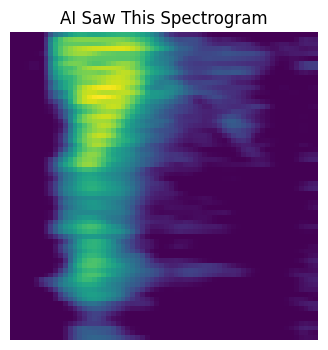

In [20]:
# 1. Grab a completely random file from the test dataset
import random
random_index = random.randint(0, len(X_test) - 1)
test_image = X_test[random_index]
true_label_encoded = y_test[random_index]

# 2. Reshape the single spectrogram image so the model can read it
# (The model expects a batch of images, so we expand dimensions from (64,64,1) to (1,64,64,1))
input_data = np.expand_dims(test_image, axis=0)

# 3. Ask the AI model to identify the spectrogram
predictions = model.predict(input_data)
predicted_class_index = np.argmax(predictions)
true_class_index = np.argmax(true_label_encoded)

# Map numbers back to our class names
class_names = classes
predicted_name = class_names[predicted_class_index]
true_name = class_names[true_class_index]

# 4. Display the result!
print("\n=== AI IDENTIFICATION RESULT ===")
print(f"AI Predicted Sound: {predicted_name.upper()}")
print(f"Actual True Sound:   {true_name.upper()}")

if predicted_name == true_name:
    print("✅ The AI identified the spectrogram correctly!")
else:
    print("❌ The AI misidentified this one.")

# Show the spectrogram image it looked at
plt.figure(figsize=(4,4))
plt.imshow(test_image.squeeze(), cmap='viridis')
plt.title(f"AI Saw This Spectrogram")
plt.axis('off')
plt.show()